# PHY241 Group Project V - Particle Discovery Experiment
### Sandrin Hunkeler, Elisabeth Giryes, Manasi Tiwari

The goal is to discover a 5 GeV meson decaying to two muons, with two parts.
1. Define a selection using a BDT to separate signal from background
2. Find how long the experiment needs to run for a 5 sigma discovery



### Setup
#### Imports

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})


#### Constants

Experiment parameters in one place. `SEED` controls every stochastic step (BDT splits and the toy MC blocks below).

In [3]:
# experiment-wide constants
SEED = 42

# signal model
MU = 5.0
SIGMA = 0.03

# analysis mass window
MASS_LO = 4.0
MASS_HI = 6.0

# yearly event rates before selection
N_SIG_PER_YEAR = 50
N_BKG_PER_YEAR = 2000

#### Load Data

In [4]:
os.makedirs('plots', exist_ok=True)

sig = pd.read_csv('data/signal_Bs2MuMu.txt', sep=r'\s+')
bkg = pd.read_csv('data/background_combinatorial.txt', sep=r'\s+')

print(f"Signal events: {len(sig)}, Background events: {len(bkg)}")
print(f"Columns: {list(sig.columns)}")
sig.head()

Signal events: 10000, Background events: 10000
Columns: ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT', 'VTXCHI2', 'ISO', 'MASS']


,Mu1_PT,Mu2_PT,Mu1_P,Mu2_P,tot_PT,VTXCHI2,ISO,MASS
0,0.504884,10.047968,108.678309,418.772201,9.948355,10.900830,-0.267760,5.431576
1,2.376916,2.867787,3.259937,5.758319,0.597111,7.726661,-0.091041,5.369218
2,2.745118,2.083754,21.563601,5.886996,1.141887,5.365485,0.426770,5.385961
3,2.456457,3.258238,36.856714,40.732084,2.099610,5.385230,-0.097810,5.344424
4,4.603657,3.143709,53.196382,10.199124,7.669011,3.700915,0.354561,5.389953


## Part 1 - Define Selection (Section 3)

### 1a - Feature histograms

We plot all 8 features to see which ones separate signal from background best.

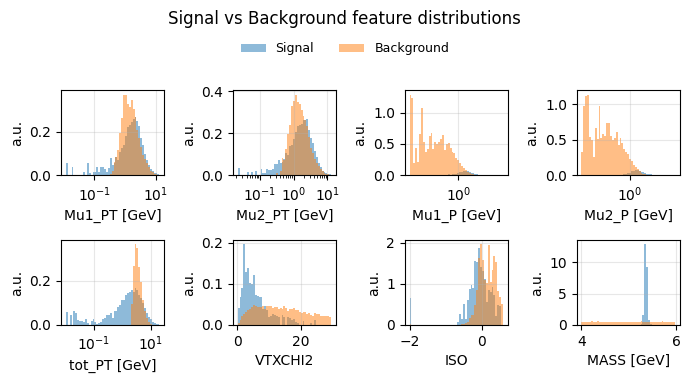

In [5]:
features = sig.columns.tolist()

units = {
    'Mu1_PT': '[GeV]', 'Mu2_PT': '[GeV]',
    'Mu1_P': '[GeV]', 'Mu2_P': '[GeV]',
    'tot_PT': '[GeV]', 'VTXCHI2': '',
    'ISO': '', 'MASS': '[GeV]',
}

# momentum features are skewed, use log x-axis
log_x_features = ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT']

fig, axes = plt.subplots(2, 4, figsize=(7, 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    use_log_x = feat in log_x_features

    # log-spaced bins for skewed features, linear otherwise
    if use_log_x:
        lo = max(min(sig[feat].min(), bkg[feat].min()), 1e-3)
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.logspace(np.log10(lo), np.log10(hi), 50)
    else:
        lo = min(sig[feat].min(), bkg[feat].min())
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.linspace(lo, hi, 50)

    ax.hist(sig[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Signal')
    ax.hist(bkg[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Background')

    if use_log_x:
        ax.set_xscale('log')

    unit = units.get(feat, '')
    ax.set_xlabel(f'{feat} {unit}'.strip())
    ax.set_ylabel('a.u.')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Signal vs Background feature distributions', y=1.08)
plt.tight_layout()
plt.savefig('plots/feature_histograms.png', dpi=200, bbox_inches='tight')
plt.show()


`VTXCHI2` and `ISO` show the clearest separation between signal and background, and `MASS` separates well too. We can't use `MASS` in the BDT because that would shape the mass distribution and bias the fit in Part 2. The momentum features overlap a lot in these histograms, but they turn out to matter for the BDT once it can combine them with the others (we'll see this in 1e).

### 1b - Fisher scores

The Fisher score quantifies how well a single feature separates two classes,

$$F = \frac{(\mu_s - \mu_b)^2}{\sigma_s^2 + \sigma_b^2}$$

Feature  Fisher Score
VTXCHI2      0.803660
   MASS      0.425375
    ISO      0.258816
  Mu2_P      0.068572
  Mu1_P      0.067968
 tot_PT      0.041046
 Mu1_PT      0.031375
 Mu2_PT      0.028887


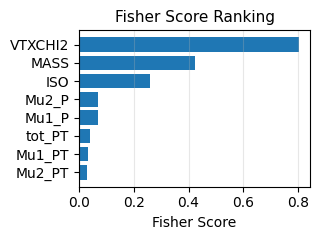


Top 3 features (excluding MASS): ['VTXCHI2', 'ISO', 'Mu2_P']


In [6]:
fisher_scores = {}
for feat in features:
    mu_s, mu_b = sig[feat].mean(), bkg[feat].mean()
    var_s, var_b = sig[feat].var(), bkg[feat].var()
    fisher_scores[feat] = (mu_s - mu_b)**2 / (var_s + var_b)

fisher_df = pd.DataFrame({
    'Feature': list(fisher_scores.keys()),
    'Fisher Score': list(fisher_scores.values())
})
fisher_df = fisher_df.sort_values('Fisher Score', ascending=False).reset_index(drop=True)

print(fisher_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(fisher_df['Feature'], fisher_df['Fisher Score'])
ax.set_xlabel('Fisher Score')
ax.set_title('Fisher Score Ranking')
ax.invert_yaxis() # highest score on top
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/fisher_scores.png', dpi=200, bbox_inches='tight')
plt.show()

# top 3 features (excluding MASS)
bdt_features_3 = [f for f in fisher_df['Feature'] if f != 'MASS'][:3]
print(f"\nTop 3 features (excluding MASS): {bdt_features_3}")

### 1c - Rectangular cuts (top 3 features)

For each of the top 3 features we scan thresholds and pick the direction (above/below) that gives the best accuracy. Events must pass all 3 cuts at the same time.

In [7]:
y_sig = np.ones(len(sig))
y_bkg = np.zeros(len(bkg))
y_all = np.concatenate([y_sig, y_bkg])

def find_best_cut(signal_values, background_values):
    all_values = np.concatenate([signal_values, background_values])
    thresholds = np.linspace(np.percentile(all_values, 1), np.percentile(all_values, 99), 200)

    best_accuracy, best_threshold, best_direction = 0, 0, '>'
    for threshold in thresholds:
        tp_gt = np.sum(signal_values > threshold)
        tn_gt = np.sum(background_values <= threshold)
        acc_gt = (tp_gt + tn_gt) / (len(signal_values) + len(background_values))

        tp_lt = np.sum(signal_values < threshold)
        tn_lt = np.sum(background_values >= threshold)
        acc_lt = (tp_lt + tn_lt) / (len(signal_values) + len(background_values))

        if acc_gt > best_accuracy:
            best_accuracy, best_threshold, best_direction = acc_gt, threshold, '>'
        if acc_lt > best_accuracy:
            best_accuracy, best_threshold, best_direction = acc_lt, threshold, '<'
    return best_threshold, best_direction, best_accuracy

cuts = {}
for feature_name in bdt_features_3:
    best_threshold, best_direction, best_accuracy = find_best_cut(sig[feature_name].values, bkg[feature_name].values)
    cuts[feature_name] = (best_threshold, best_direction)
    print(f"{feature_name}: cut {best_direction} {best_threshold:.4f}, accuracy = {best_accuracy:.4f}")

# apply all 3 cuts at once
sig_pass = np.ones(len(sig), dtype=bool)
bkg_pass = np.ones(len(bkg), dtype=bool)

for feature_name, (threshold, direction) in cuts.items():
    if direction == '>':
        sig_pass = sig_pass & (sig[feature_name].values > threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values > threshold)
    else:
        sig_pass = sig_pass & (sig[feature_name].values < threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values < threshold)

rect_acc = (np.sum(sig_pass) + np.sum(~bkg_pass)) / (len(sig) + len(bkg))
print(f"\nCombined rectangular cut accuracy: {rect_acc:.4f}")
print(f"Signal eff: {np.mean(sig_pass):.4f}, Bkg rejection: {1 - np.mean(bkg_pass):.4f}")

VTXCHI2: cut < 7.8676, accuracy = 0.7498
ISO: cut < -0.0864, accuracy = 0.6720
Mu2_P: cut > 4.7525, accuracy = 0.7654

Combined rectangular cut accuracy: 0.6352
Signal eff: 0.2814, Bkg rejection: 0.9891


### 1d - BDT with 3 features

We train a Boosted Decision Tree (BDT), using sklearn's Gradient Boosting classifier, on the same 3 features. BDTs can capture non-linear boundaries that rectangular cuts miss, so the accuracy should improve. We split the data 50/50 into train and test to check for overfitting.

In [8]:
X_all = pd.concat([sig, bkg], ignore_index=True)
y_all = np.concatenate([np.ones(len(sig)), np.zeros(len(bkg))])

# 50/50 train/test split to avoid overfitting bias
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.5, random_state=SEED
)

bdt_3 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
bdt_3.fit(X_train[bdt_features_3], y_train)

acc_train_3 = accuracy_score(y_train, bdt_3.predict(X_train[bdt_features_3]))
acc_3 = accuracy_score(y_test, bdt_3.predict(X_test[bdt_features_3]))

print(f"BDT 3-feat train acc: {acc_train_3:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Rectangular cuts:     {rect_acc:.4f}")
print(f"Train ~ test, so no overfitting.")

BDT 3-feat train acc: 0.9228
BDT 3-feat test acc:  0.9115
Rectangular cuts:     0.6352
Train ~ test, so no overfitting.


### 1e - BDT with 7 features

Now we use all features except MASS and see how much the accuracy improves. We also look at the feature importances from the BDT.

BDT 7-feat train acc: 0.9766
BDT 7-feat test acc:  0.9644
BDT 3-feat test acc:  0.9115
Again train ~ test, no overfitting.


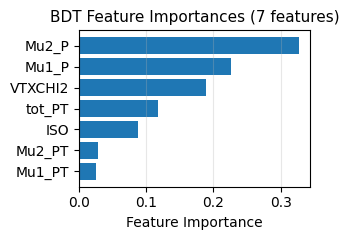

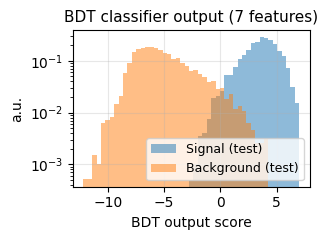

In [9]:
# exclude MASS, otherwise the BDT would just learn the peak
bdt_features_7 = [f for f in features if f != 'MASS']

bdt_7 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
bdt_7.fit(X_train[bdt_features_7], y_train)

acc_train_7 = accuracy_score(y_train, bdt_7.predict(X_train[bdt_features_7]))
acc_7 = accuracy_score(y_test, bdt_7.predict(X_test[bdt_features_7]))

print(f"BDT 7-feat train acc: {acc_train_7:.4f}")
print(f"BDT 7-feat test acc:  {acc_7:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Again train ~ test, no overfitting.")

importances = bdt_7.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(np.array(bdt_features_7)[sorted_idx], importances[sorted_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('BDT Feature Importances (7 features)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/bdt_importances.png', dpi=200, bbox_inches='tight')
plt.show()

scores_sig = bdt_7.decision_function(X_test[bdt_features_7][y_test == 1])
scores_bkg = bdt_7.decision_function(X_test[bdt_features_7][y_test == 0])

fig, ax = plt.subplots(figsize=(3.3, 2.5))
lo_s = min(scores_sig.min(), scores_bkg.min())
hi_s = max(scores_sig.max(), scores_bkg.max())
bins_score = np.linspace(lo_s, hi_s, 50)

ax.hist(scores_sig, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Signal (test)')
ax.hist(scores_bkg, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Background (test)')
ax.set_xlabel('BDT output score')
ax.set_ylabel('a.u.')
ax.set_title('BDT classifier output (7 features)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bdt_score_dist.png', dpi=200, bbox_inches='tight')
plt.show()

### 1f - Apply BDT selection

Apply the 7-feature BDT to both samples and measure signal efficiency (fraction of signal we keep) and background efficiency (fraction of background that leaks through). Higher signal eff and lower background eff is better.

We evaluate on the test set only. Using all events would include training data and bias the numbers upward.

Signal efficiency:     0.9774 +/- 0.0021
Background efficiency: 0.0487 +/- 0.0031
Signal passing:     4920 / 5034
Background passing: 242 / 4966


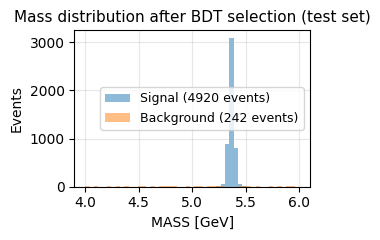

In [10]:
# evaluate on test set only to avoid overfitting bias
sig_test = X_test[y_test == 1]
bkg_test = X_test[y_test == 0]

sig_pred = bdt_7.predict(sig_test[bdt_features_7])
bkg_pred = bdt_7.predict(bkg_test[bdt_features_7])

sig_eff = np.mean(sig_pred == 1)
bkg_eff = np.mean(bkg_pred == 1)

# binomial uncertainties (our addition, not required)
n_sig_test = len(sig_test)
n_bkg_test = len(bkg_test)
sig_eff_err = np.sqrt(sig_eff * (1 - sig_eff) / n_sig_test)
bkg_eff_err = np.sqrt(bkg_eff * (1 - bkg_eff) / n_bkg_test)

print(f"Signal efficiency:     {sig_eff:.4f} +/- {sig_eff_err:.4f}")
print(f"Background efficiency: {bkg_eff:.4f} +/- {bkg_eff_err:.4f}")
print(f"Signal passing:     {np.sum(sig_pred == 1)} / {n_sig_test}")
print(f"Background passing: {np.sum(bkg_pred == 1)} / {n_bkg_test}")

sig_mass = sig_test.loc[sig_pred == 1, 'MASS'].values
bkg_mass = bkg_test.loc[bkg_pred == 1, 'MASS'].values

fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 50)
ax.hist(sig_mass, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Signal ({len(sig_mass)} events)')
ax.hist(bkg_mass, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Background ({len(bkg_mass)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title('Mass distribution after BDT selection (test set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/mass_after_bdt.png', dpi=200, bbox_inches='tight')
plt.show()

## Part 2 - Experiment Duration (Section 4)

### 2a - Composite PDF and toy generation

We fit the background mass shape from the full background sample (all 10k events), then build a composite model to generate toy experiments. The assignment says to establish the exponential on the background.txt sample. We minimize the negative log-likelihood (NLL) to find the best-fit lambda.

The signal is a Gaussian at 5 GeV with width 0.03, the background is exponential in [4, 6] GeV. After the BDT we expect 50 signal and 2000 background events per year times the efficiencies.

Fitted lambda = 0.0283


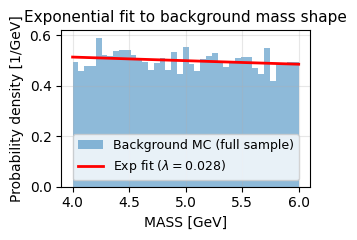


Expected events per year:
  Signal:     48.9
  Background: 97.5


In [11]:
def exp_nll(lam, data):
    Z = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    return -np.sum(-lam * data) + len(data) * np.log(Z)

# fit lambda from the full background sample (not just post-BDT)
bkg_mass = bkg['MASS'].values
fit_result = optimize.minimize_scalar(lambda slope: exp_nll(slope, bkg_mass), bounds=(-5, 5), method='bounded')
lambda_fit = fit_result.x

print(f"Fitted lambda = {lambda_fit:.4f}")

fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 40)
ax.hist(bkg_mass, bins=bins, density=True, histtype='stepfilled',
        alpha=0.5, label='Background MC (full sample)')
m_plot = np.linspace(MASS_LO, MASS_HI, 200)
Z = (np.exp(-lambda_fit * MASS_LO) - np.exp(-lambda_fit * MASS_HI)) / lambda_fit
ax.plot(m_plot, np.exp(-lambda_fit * m_plot) / Z, 'r-', lw=2, label=f'Exp fit ($\\lambda={lambda_fit:.3f}$)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Probability density [1/GeV]')
ax.set_title('Exponential fit to background mass shape')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/exp_fit.png', dpi=200, bbox_inches='tight')
plt.show()

n_sig_per_year = N_SIG_PER_YEAR * sig_eff
n_bkg_per_year = N_BKG_PER_YEAR * bkg_eff
print(f"\nExpected events per year:")
print(f"  Signal:     {n_sig_per_year:.1f}")
print(f"  Background: {n_bkg_per_year:.1f}")

We generate 1000 toy datasets for 1 year of running. For each toy we Poisson-fluctuate the event counts and sample masses from the PDFs above.

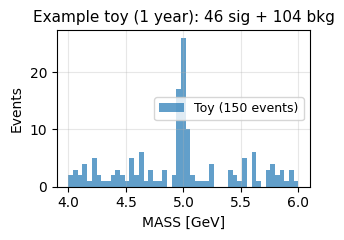

In [12]:
def sample_truncated_exp(lam, lo, hi, size):
    # inverse CDF sampling
    u = np.random.uniform(0, 1, size)
    c_lo = np.exp(-lam * lo)
    c_hi = np.exp(-lam * hi)
    return -np.log(c_lo - u * (c_lo - c_hi)) / lam

def sample_truncated_gauss(mu, sigma, lo, hi, size):
    # inverse CDF on the truncated Gaussian
    u = np.random.uniform(0, 1, size)
    c_lo = norm.cdf(lo, mu, sigma)
    c_hi = norm.cdf(hi, mu, sigma)
    return norm.ppf(c_lo + u * (c_hi - c_lo), mu, sigma)

def generate_toy(mu_sig, mu_bkg, lam):
    n_sig_sampled = np.random.poisson(mu_sig)
    n_bkg_sampled = np.random.poisson(mu_bkg)
    m_s = sample_truncated_gauss(MU, SIGMA, MASS_LO, MASS_HI, n_sig_sampled)
    m_b = sample_truncated_exp(lam, MASS_LO, MASS_HI, n_bkg_sampled)
    # shuffle so sig/bkg are mixed
    m_toy = np.concatenate([m_s, m_b])
    np.random.shuffle(m_toy)
    return m_toy, n_sig_sampled, n_bkg_sampled

# generate one toy for 1 year as a sanity check
np.random.seed(SEED)
m_toy, n_sig_sampled, n_bkg_sampled = generate_toy(
    n_sig_per_year, n_bkg_per_year, lambda_fit
)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 50)
ax.hist(m_toy, bins=bins, histtype='stepfilled', alpha=0.7,
        label=f'Toy ({len(m_toy)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title(f'Example toy (1 year): {n_sig_sampled} sig + {n_bkg_sampled} bkg')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/toy_example.png', dpi=200, bbox_inches='tight')
plt.show()

### 2b - Fit toys and signal fraction

For each toy we fit a composite model, $f(m) = f_\text{sig} \cdot f_s(m) + (1 - f_\text{sig}) \cdot f_b(m)$, where $f_\text{sig}$ is the signal fraction. We compare a signal+background fit (free params $f_\text{sig}$ and $\lambda$) against a background-only fit (only $\lambda$). Gaussian mean and width are fixed from the known signal properties.

True f_sig: 0.3340
Mean fitted f_sig: 0.3348 +/- 0.0434
Mean H1 lambda: 0.0239 +/- 0.1790
Background-only lambda (full sample): 0.0283
Fraction of toys with f_sig pinned at 0: 0.000
Std of one-year significances: 1.29 sigma


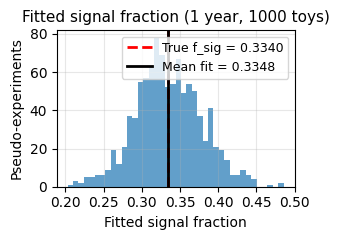

In [13]:
def gauss_pdf(m):
    Z = norm.cdf(MASS_HI, MU, SIGMA) - norm.cdf(MASS_LO, MU, SIGMA)
    return norm.pdf(m, MU, SIGMA) / Z

def exp_pdf(m, lam):
    Z = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    return np.exp(-lam * m) / Z

def composite_nll(params, m_toy):
    fs, lam = params
    pdf = fs * gauss_pdf(m_toy) + (1 - fs) * exp_pdf(m_toy, lam)
    pdf[pdf < 1e-300] = 1e-300 
    return -np.sum(np.log(pdf))

def bkg_only_nll(params, m_toy):
    lam = params[0]
    pdf = exp_pdf(m_toy, lam)
    pdf[pdf < 1e-300] = 1e-300 
    return -np.sum(np.log(pdf))

def fit_toy(m_toy):
    res_sb = optimize.minimize(
        composite_nll, x0=[0.1, lambda_fit], args=(m_toy,),
        bounds=[(0, 1), (-10, 10)], method='L-BFGS-B'
    )
    fs_hat, lam_hat = res_sb.x
    nll_sb = res_sb.fun

    res_b = optimize.minimize(
        bkg_only_nll, x0=[lambda_fit], args=(m_toy,),
        bounds=[(-10, 10)], method='L-BFGS-B'
    )
    nll_b = res_b.fun

    return fs_hat, lam_hat, nll_sb, nll_b

# run 1000 toys for 1 year
np.random.seed(SEED)
n_toys = 1000
fs_list = []
Z_list = []
lam_list = []

for _ in range(n_toys):
    m_toy, _, _ = generate_toy(
        n_sig_per_year, n_bkg_per_year, lambda_fit
    )
    fs_hat, lam_hat, nll_sb, nll_b = fit_toy(m_toy)
    fs_list.append(fs_hat)
    # also keep H1 lambda for the cross-check
    lam_list.append(lam_hat)
    q = 2 * (nll_b - nll_sb)
    q = max(q, 0) # q can go slightly negative numerically
    Z_list.append(np.sqrt(q))

fs_list = np.array(fs_list)
Z_list = np.array(Z_list)
lam_list = np.array(lam_list)
fs_true = n_sig_per_year / (n_sig_per_year + n_bkg_per_year)

print(f"True f_sig: {fs_true:.4f}")
print(f"Mean fitted f_sig: {np.mean(fs_list):.4f} +/- {np.std(fs_list):.4f}")
print(f"Mean H1 lambda: {np.mean(lam_list):.4f} +/- {np.std(lam_list):.4f}")
print(f"Background-only lambda (full sample): {lambda_fit:.4f}")
frac_at_zero = float(np.mean(fs_list <= 1e-6))
print(f"Fraction of toys with f_sig pinned at 0: {frac_at_zero:.3f}")
print(f"Std of one-year significances: {np.std(Z_list):.2f} sigma")

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(fs_list, bins=40, alpha=0.7)
ax.axvline(fs_true, color='r', ls='--', lw=2, label=f'True f_sig = {fs_true:.4f}')
ax.axvline(np.mean(fs_list), color='k', ls='-', lw=2, label=f'Mean fit = {np.mean(fs_list):.4f}')
ax.set_xlabel('Fitted signal fraction')
ax.set_ylabel('Pseudo-experiments')
ax.set_xticks(np.arange(0.20, 0.51, 0.05))
ax.set_title('Fitted signal fraction (1 year, 1000 toys)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/fsig_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

The mean fitted signal fraction matches the true value, so the fit is unbiased.

### 2c - Significance distribution

By Wilks' theorem, $q = 2(\text{NLL}_{\text{bkg}} - \text{NLL}_{s+b})$ follows $\chi^2(1)$ under the null hypothesis, so the significance in sigma is $\sqrt{q}$.

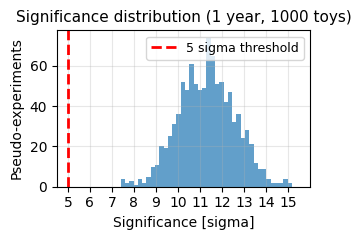

Mean significance: 11.31 sigma
Median significance: 11.33 sigma
Fraction >5 sigma: 1.000


In [14]:
frac_above_5 = np.mean(Z_list > 5)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(Z_list, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_xlim(4.5, 16)
ax.set_xticks(np.arange(5, 16))
ax.set_title(f'Significance distribution (1 year, {n_toys} toys)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mean significance: {np.mean(Z_list):.2f} sigma")
print(f"Median significance: {np.median(Z_list):.2f} sigma")
print(f"Fraction >5 sigma: {frac_above_5:.3f}")

### 2d - Required experiment duration

We repeat the toy study for different run durations (scaling event counts linearly with time) and find when 95% of toys exceed 5 sigma.

   1.0 months: 0.071
   1.1 months: 0.098
   1.2 months: 0.128
   1.3 months: 0.148
   1.4 months: 0.202
   1.5 months: 0.199
   1.6 months: 0.245
   1.7 months: 0.273
   1.8 months: 0.293
   1.9 months: 0.317
   2.0 months: 0.385
   2.1 months: 0.435
   2.2 months: 0.496
   2.3 months: 0.495
   2.4 months: 0.524
   2.5 months: 0.573
   2.6 months: 0.565
   2.7 months: 0.607
   2.8 months: 0.634
   2.9 months: 0.659
   3.0 months: 0.709
   3.1 months: 0.733
   3.2 months: 0.737
   3.3 months: 0.749
   3.4 months: 0.786
   3.5 months: 0.787
   3.6 months: 0.838
   3.7 months: 0.805
   3.8 months: 0.850
   3.9 months: 0.875
   4.0 months: 0.881
   4.1 months: 0.908
   4.2 months: 0.909
   4.3 months: 0.913
   4.4 months: 0.910
   4.5 months: 0.916
   4.6 months: 0.932
   4.7 months: 0.951
   4.8 months: 0.952
   4.9 months: 0.947
   5.0 months: 0.961
   5.1 months: 0.960
   5.2 months: 0.969
   5.3 months: 0.979
   5.4 months: 0.976
   5.5 months: 0.980
   5.6 months: 0.978
   5.7 months

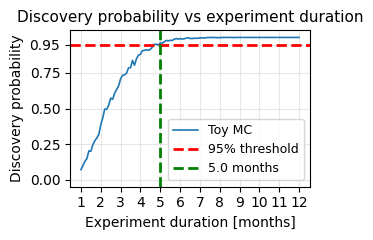

In [15]:
months_to_scan = np.arange(1.0, 12.05, 0.1).round(1)
n_toys_per_duration = 1000
probs = []

np.random.seed(SEED)
for T_months in months_to_scan:
    T_years = T_months / 12.0
    mu_sig = n_sig_per_year * T_years
    mu_bkg = n_bkg_per_year * T_years

    n_pass = 0
    for _ in range(n_toys_per_duration):
        m_toy, _, _ = generate_toy(mu_sig, mu_bkg, lambda_fit)
        _, _, nll_sb, nll_b = fit_toy(m_toy)
        q = max(2 * (nll_b - nll_sb), 0)
        if np.sqrt(q) > 5:
            n_pass += 1

    p = n_pass / n_toys_per_duration
    probs.append(p)
    print(f"  {T_months:4.1f} months: {p:.3f}")

probs = np.array(probs)

above_95 = probs >= 0.95
bad = np.where(~above_95)[0]
t95_idx = bad[-1] + 1 if len(bad) else 0
t95_months = float(months_to_scan[t95_idx])

good = np.where(above_95)[0]
t95_first = float(months_to_scan[good[0]])

print(f"\nFirst crossing of 95% (lower edge of uncertainty band): {t95_first:.1f} months")
print(f"Sustained 95% from (conservative answer): {t95_months:.1f} months")

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.plot(months_to_scan, probs, '-', lw=1.2, label='Toy MC')
ax.axhline(0.95, color='r', ls='--', lw=2, label='95% threshold')
ax.axvline(t95_months, color='g', ls='--', lw=2, label=f'{t95_months:.1f} months')
ax.set_xlabel('Experiment duration [months]')
ax.set_ylabel('Discovery probability')
ax.set_xticks(np.arange(1, 13))
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 0.95])
ax.set_title('Discovery probability vs experiment duration')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/discovery_duration.png', dpi=200, bbox_inches='tight')
plt.show()

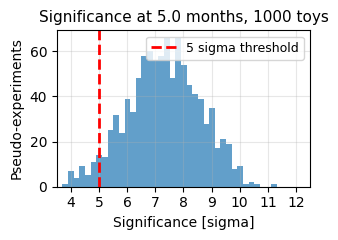

At 5.0 months:
  Mean significance:   7.28 sigma
  Median significance: 7.31 sigma
  Std of significances: 1.30 sigma
  Fraction > 5 sigma:  0.954


In [16]:
# extra plot at the discovery duration (our addition). At 1 year we're far above 5 sigma, so a histogram at t95 is more informative.
T_thr = t95_months
T_thr_years = T_thr / 12.0
mu_sig = n_sig_per_year * T_thr_years
mu_bkg = n_bkg_per_year * T_thr_years

np.random.seed(SEED)
Z_thr = []
for _ in range(n_toys):
    m_toy, _, _ = generate_toy(
        mu_sig, mu_bkg, lambda_fit
    )
    _, _, nll_sb, nll_b = fit_toy(m_toy)
    q = max(2 * (nll_b - nll_sb), 0)
    Z_thr.append(np.sqrt(q))
Z_thr = np.array(Z_thr)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(Z_thr, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_xlim(3.5, 12.5)
ax.set_xticks(np.arange(4, 13))
ax.set_title(f'Significance at {T_thr:.1f} months, {n_toys} toys')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist_threshold.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"At {T_thr:.1f} months:")
print(f"  Mean significance:   {np.mean(Z_thr):.2f} sigma")
print(f"  Median significance: {np.median(Z_thr):.2f} sigma")
print(f"  Std of significances: {np.std(Z_thr):.2f} sigma")
print(f"  Fraction > 5 sigma:  {np.mean(Z_thr > 5):.3f}")

## Summary

The 7-feature BDT reaches 96.44% test accuracy with train/test agreement still good, so overfitting is under control. We measure efficiencies on the test set only (as required) and get signal efficiency = 0.9774 +/- 0.0021 and background efficiency = 0.0487 +/- 0.0031.

With these efficiencies, the 1-year toy study gives a mean significance of 11.31 sigma, and 100.0% of toys exceed 5 sigma. Scanning run duration on a 0.1-month grid, the noisy estimate first reaches 95% at 4.7 months but dips back to 94.7% at 4.9 months due to per-grid binomial noise of order 0.7%. From 5.0 months onwards the discovery probability stays at or above 95%. We adopt 5.0 months as the conservative answer, with 4.7 months being the lower edge of the uncertainty band.